Diabetes Prediction


In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("diabetes_dataset.csv")

In [3]:
ds=df.copy()

In [4]:
df

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [6]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [7]:
df["diagnosed_diabetes"].value_counts()

diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

In [8]:
def find_outliers(df, columns):
    """
    Find outliers using the IQR method.

    Parameters:
        df (pd.DataFrame): Input DataFrame
        columns (list): List of numerical columns

    Returns:
        dict: Dictionary containing outlier DataFrames for each column
    """
    outliers = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_rows = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outliers[col] = outlier_rows

        print(f"\nColumn: {col}")
        print(f"Lower Bound : {lower_bound:.2f}")
        print(f"Upper Bound : {upper_bound:.2f}")
        print(f"Number of Outliers : {len(outlier_rows)}")

    return outliers

In [9]:
find_outliers(df, ["family_history_diabetes"])


Column: family_history_diabetes
Lower Bound : 0.00
Upper Bound : 0.00
Number of Outliers : 21941


{'family_history_diabetes':        age  gender ethnicity education_level  income_level employment_status  \
 2       60    Male  Hispanic      Highschool        Middle        Unemployed   
 23      27  Female  Hispanic      Highschool           Low          Employed   
 26      32  Female     White      Highschool        Middle           Retired   
 29      45  Female     Black        Graduate  Lower-Middle           Retired   
 34      63    Male     White      Highschool           Low          Employed   
 ...    ...     ...       ...             ...           ...               ...   
 99960   72    Male     White      Highschool  Upper-Middle           Retired   
 99961   57    Male     Black      Highschool  Upper-Middle          Employed   
 99967   44  Female     White       No formal        Middle          Employed   
 99971   33    Male     White    Postgraduate  Upper-Middle          Employed   
 99973   62    Male     Other      Highschool          High           Retired   
 

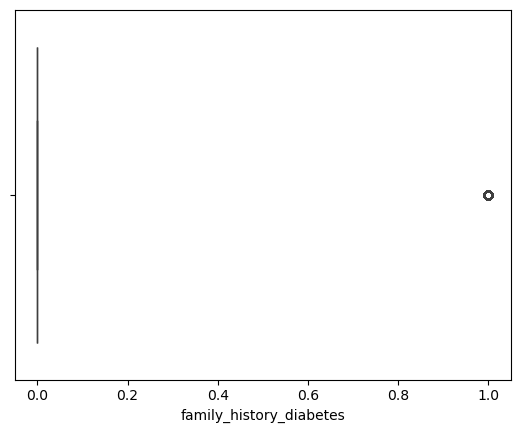

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["family_history_diabetes"])
plt.show()

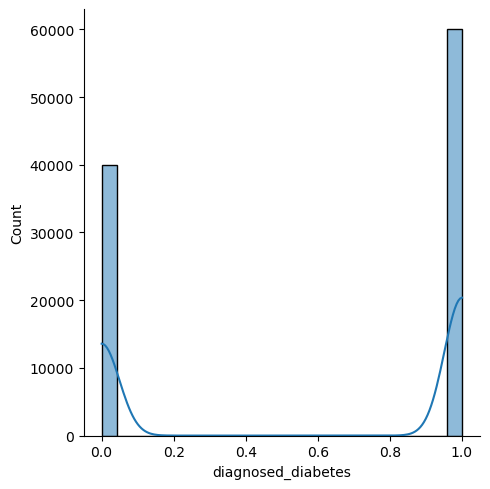

In [11]:
sns.displot(data=df,x="diagnosed_diabetes",kde=True)

In [12]:
## Univariate Analysis
!pip install sweetviz 
#installing sweetviz library`

In [13]:
import sweetviz as sv                       #importing sweetviz library 
my_report = sv.analyze(df)                #syntax to use sweetviz
my_report.show_html()                       #Default arguments will generate to "SWEETVIZ_REPORT.html"

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [15]:
df["gender"]

0          Male
1        Female
2          Male
3        Female
4          Male
          ...  
99995      Male
99996    Female
99997    Female
99998    Female
99999    Female
Name: gender, Length: 100000, dtype: object

In [16]:
df.gender=le.fit_transform(df.gender)

In [17]:
df['ethnicity'].value_counts()

ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

In [18]:
df = pd.get_dummies(df, columns=['ethnicity'], drop_first=True, dtype=int)


In [19]:
df

,age,gender,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,...,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White
0,58,1,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,...,236,6.36,8.18,29.6,Type 2,1,0,0,0,0
1,48,0,Highschool,Middle,Employed,Former,1,143,6.7,6.5,...,150,2.00,5.63,23.0,No Diabetes,0,0,0,0,1
2,60,1,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,...,195,5.07,7.51,44.7,Type 2,1,0,1,0,0
3,74,0,Highschool,Low,Retired,Never,0,49,3.4,6.6,...,253,5.28,9.03,38.2,Type 2,1,1,0,0,0
4,46,1,Graduate,Middle,Retired,Never,1,109,7.2,7.4,...,184,12.74,7.20,23.5,Type 2,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,1,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,6.4,...,109,14.58,5.55,26.0,Pre-Diabetes,0,0,0,1,0
99996,41,0,Graduate,Middle,Employed,Never,3,76,8.8,6.8,...,146,9.02,5.97,24.4,Pre-Diabetes,0,0,0,0,1
99997,57,0,No formal,Upper-Middle,Employed,Former,4,121,9.9,5.0,...,132,2.57,5.21,27.6,No Diabetes,0,1,0,0,0
99998,47,0,Highschool,Lower-Middle,Retired,Never,3,52,5.9,6.7,...,117,9.81,5.53,26.4,Pre-Diabetes,0,1,0,0,0


In [20]:
df["education_level"].value_counts()

education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

In [21]:
df.education_level=df.education_level.map({"Highschool":1,"Graduate":2,"Postgraduate":3,"No formal":4})

In [22]:
df["smoking_status"]

0         Never
1        Former
2         Never
3         Never
4         Never
          ...  
99995    Former
99996     Never
99997    Former
99998     Never
99999     Never
Name: smoking_status, Length: 100000, dtype: object

In [23]:
df.smoking_status=le.fit_transform(df.smoking_status)

In [24]:
df.diabetes_stage.value_counts()

diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64

In [25]:
df=pd.get_dummies(df,columns=["diabetes_stage"], drop_first=True, dtype=int)

In [26]:
df["income_level"].value_counts()

income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

In [27]:
df.income_level=df.income_level.map({"Middle":1,"Lower-Middle":2,"Upper-Middle":3,"Low":4,"High":5})

In [28]:
df["employment_status"].value_counts()

employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

In [29]:
df=pd.get_dummies(df,columns=["employment_status"], drop_first=True, dtype=int)

In [30]:
df

,age,gender,education_level,income_level,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,...,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,diabetes_stage_No Diabetes,diabetes_stage_Pre-Diabetes,diabetes_stage_Type 1,diabetes_stage_Type 2,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,58,1,1,2,2,0,215,5.7,7.9,7.9,...,0,0,0,0,0,0,1,0,0,0
1,48,0,1,1,1,1,143,6.7,6.5,8.7,...,0,0,1,1,0,0,0,0,0,0
2,60,1,1,1,2,1,57,6.4,10.0,8.1,...,1,0,0,0,0,0,1,0,0,1
3,74,0,1,4,2,0,49,3.4,6.6,5.2,...,0,0,0,0,0,0,1,1,0,0
4,46,1,2,1,2,1,109,7.2,7.4,5.0,...,0,0,1,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,1,2,3,1,1,136,8.3,6.4,4.5,...,0,1,0,0,1,0,0,0,0,1
99996,41,0,2,1,2,3,76,8.8,6.8,4.8,...,0,0,1,0,1,0,0,0,0,0
99997,57,0,4,3,1,4,121,9.9,5.0,6.1,...,0,0,0,1,0,0,0,0,0,0
99998,47,0,1,2,2,3,52,5.9,6.7,0.5,...,0,0,0,0,1,0,0,1,0,0


In [32]:
x=df.drop("diagnosed_diabetes",axis=1)
y=df["diagnosed_diabetes"]

In [33]:
x

,age,gender,education_level,income_level,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,...,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,diabetes_stage_No Diabetes,diabetes_stage_Pre-Diabetes,diabetes_stage_Type 1,diabetes_stage_Type 2,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,58,1,1,2,2,0,215,5.7,7.9,7.9,...,0,0,0,0,0,0,1,0,0,0
1,48,0,1,1,1,1,143,6.7,6.5,8.7,...,0,0,1,1,0,0,0,0,0,0
2,60,1,1,1,2,1,57,6.4,10.0,8.1,...,1,0,0,0,0,0,1,0,0,1
3,74,0,1,4,2,0,49,3.4,6.6,5.2,...,0,0,0,0,0,0,1,1,0,0
4,46,1,2,1,2,1,109,7.2,7.4,5.0,...,0,0,1,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,1,2,3,1,1,136,8.3,6.4,4.5,...,0,1,0,0,1,0,0,0,0,1
99996,41,0,2,1,2,3,76,8.8,6.8,4.8,...,0,0,1,0,1,0,0,0,0,0
99997,57,0,4,3,1,4,121,9.9,5.0,6.1,...,0,0,0,1,0,0,0,0,0,0
99998,47,0,1,2,2,3,52,5.9,6.7,0.5,...,0,0,0,0,1,0,0,1,0,0


In [34]:
y

0        1
1        0
2        1
3        1
4        1
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diagnosed_diabetes, Length: 100000, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [37]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
model = DecisionTreeClassifier()

In [39]:
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [40]:
base_pred = model.predict(x_test)

In [41]:
#evalution
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [42]:
confusion_matrix(y_test,base_pred)

array([[12053,    14],
       [   11, 17922]])

In [43]:
print(classification_report(y_test,base_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12067
           1       1.00      1.00      1.00     17933

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



In [45]:
from sklearn.ensemble import RandomForestClassifier

Model = RandomForestClassifier(
    random_state=42
)

Model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
pred=Model.predict(x_test)

In [47]:
confusion_matrix(y_test,base_pred)

array([[12053,    14],
       [   11, 17922]])

In [48]:
print(classification_report(y_test,base_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12067
           1       1.00      1.00      1.00     17933

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



In [50]:
import joblib

joblib.dump(Model, "random_forest_model.pkl")

['random_forest_model.pkl']